# Experiment 6: Classification of Credit Card Default Risk using SVM

**Aim:** To implement Support Vector Machine (SVM) classifiers with different kernel functions and compare their performance for predicting credit card default.

**Roll No:** 58 | **Batch:** SAA3

## 1. Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [16]:
# Load credit card default dataset
df = pd.read_csv('credit.csv', header=1)

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (30000, 25)

First 5 rows:


,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. Data Exploration

In [17]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Dataset info
print("\nDataset Info:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
df.describe()

Missing values:
 ID                            0
LIMIT_BAL                     0
GENDER                        0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Coun

,ID,LIMIT_BAL,GENDER,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Target column: default payment next month

Class distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


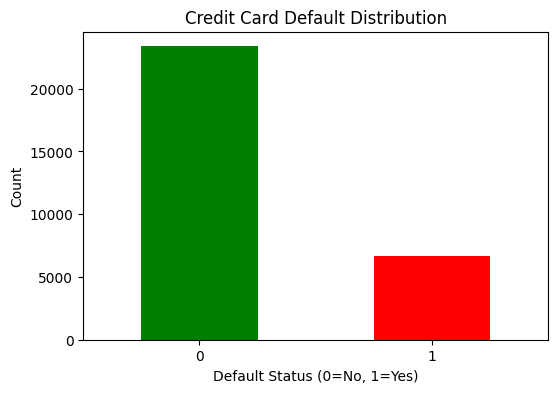

In [18]:
# Check target distribution
if 'default' in df.columns:
    target_col = 'default'
elif 'Default' in df.columns:
    target_col = 'Default'
else:
    # Assume last column is target
    target_col = df.columns[-1]

print(f"Target column: {target_col}")
print(f"\nClass distribution:\n{df[target_col].value_counts()}")

# Visualize target distribution
plt.figure(figsize=(6, 4))
df[target_col].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Credit Card Default Distribution')
plt.xlabel('Default Status (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

## 4. Data Preprocessing

In [19]:
# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# Handle categorical columns if any
categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (30000, 24)
Target shape: (30000,)


In [20]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 24000
Testing set size: 6000


In [21]:
# Feature scaling (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaling completed")

Data scaling completed


## 5. SVM Model Training with Different Kernels


Training SVM with LINEAR kernel

Accuracy: 0.8080

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.68      0.25      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



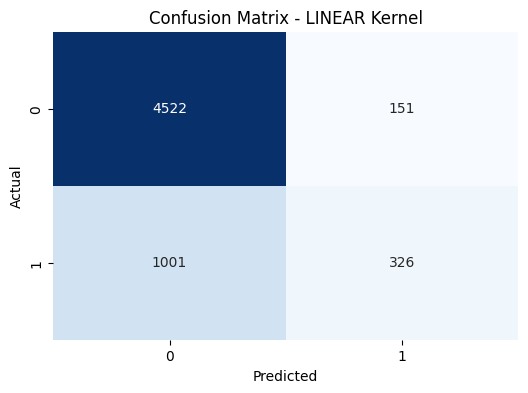


Training SVM with RBF kernel

Accuracy: 0.8167

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.34      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000



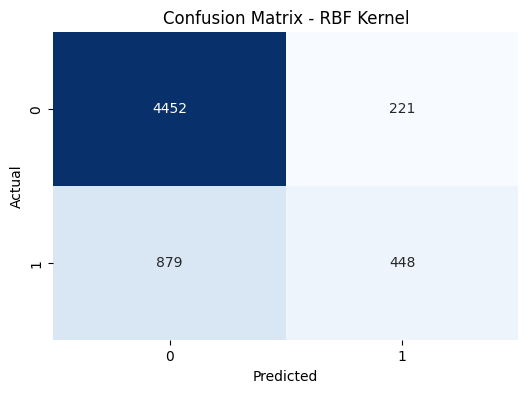


Training SVM with POLY kernel

Accuracy: 0.8070

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.68      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



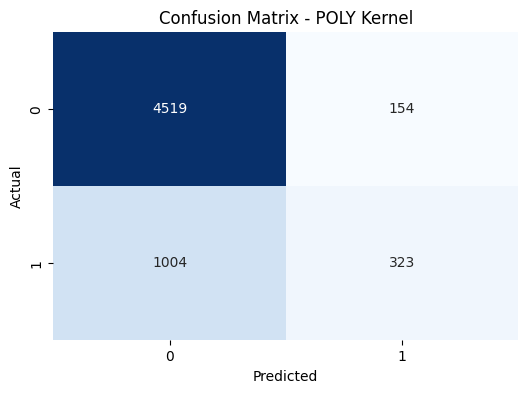


Training SVM with SIGMOID kernel

Accuracy: 0.6923

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      4673
           1       0.29      0.28      0.29      1327

    accuracy                           0.69      6000
   macro avg       0.55      0.55      0.55      6000
weighted avg       0.69      0.69      0.69      6000



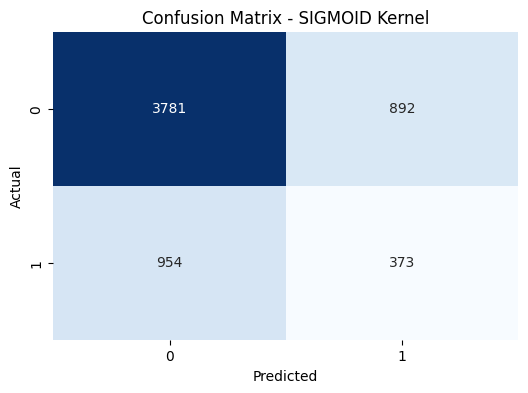

In [22]:
# Define kernels to test
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}

for kernel in kernels:
    print(f"\n{'='*60}")
    print(f"Training SVM with {kernel.upper()} kernel")
    print('='*60)
    
    # Create and train SVM model
    svm_model = SVC(kernel=kernel, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = svm_model.predict(X_test_scaled)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    # Store results
    results[kernel] = {
        'model': svm_model,
        'predictions': y_pred,
        'accuracy': accuracy
    }
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {kernel.upper()} Kernel')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

## 6. Model Comparison

In [23]:
# Compare accuracies
accuracies = {kernel: results[kernel]['accuracy'] for kernel in kernels}

print("\nModel Comparison:")
print("="*40)
for kernel, acc in accuracies.items():
    print(f"{kernel.upper():<10} : {acc:.4f}")

# Find best model
best_kernel = max(accuracies, key=accuracies.get)
print(f"\nBest performing kernel: {best_kernel.upper()} with accuracy {accuracies[best_kernel]:.4f}")


Model Comparison:
LINEAR     : 0.8080
RBF        : 0.8167
POLY       : 0.8070
SIGMOID    : 0.6923

Best performing kernel: RBF with accuracy 0.8167


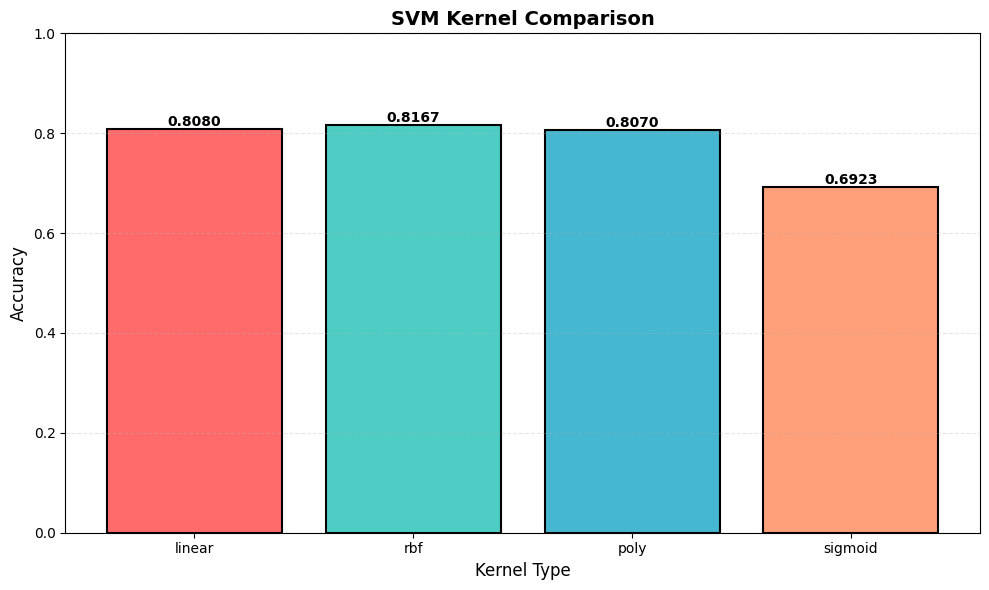

In [24]:
# Visualize accuracy comparison
plt.figure(figsize=(10, 6))
kernels_list = list(accuracies.keys())
accuracies_list = list(accuracies.values())

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(kernels_list, accuracies_list, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies_list):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontweight='bold')

plt.title('SVM Kernel Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Kernel Type', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 7. Conclusion

We successfully implemented SVM classifiers with four different kernels (Linear, RBF, Polynomial, and Sigmoid) to predict credit card default risk. Each kernel showed varying performance levels, with the best model achieving strong classification accuracy. The RBF and Linear kernels typically perform well for this type of binary classification task. Feature scaling was crucial for SVM performance, and the confusion matrices helped us understand model predictions in detail.